<a href="https://colab.research.google.com/github/No-man1234/Sepsis_Prediction_Model/blob/main/Sepsis_Detection_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICU Sepsis Prediction - Early Warning System
This notebook implements an early warning system for sepsis prediction based on the PhysioNet/CinC Challenge 2019 dataset.

## Table of Contents
1. Google Drive Mounting & Environment Setup
2. Data Downloading
3. Data Loading & Preprocessing (Saving Processed Data)
4. Exploratory Data Analysis (EDA)
5. Feature Engineering & Imputation
6. Handling Class Imbalance (SMOTE)
7. Model Training (Random Forest & XGBoost) & Saving Models
8. Evaluation & Visualizations (Saving Results)
9. Model Interpretability (SHAP)


## 1. Google Drive Mounting & Environment Setup
We will mount your Google Drive so that we can permanently save the processed dataset, the trained models, and our visualizations.


In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a project folder in your Drive
project_dir = '/content/drive/MyDrive/Sepsis_Detection_Project'
os.makedirs(project_dir, exist_ok=True)
print(f"\nAll results, datasets, and models will be saved to: {project_dir}")

!pip install xgboost shap imbalanced-learn scikit-learn pandas matplotlib seaborn joblib


Mounted at /content/drive

All results, datasets, and models will be saved to: /content/drive/MyDrive/Sepsis_Detection_Project


## 2. Data Downloading
The PhysioNet dataset is hosted as thousands of individual `.psv` files. We use a multi-threaded downloader to fetch both `training_setA` and `training_setB` quickly into Colab's temporary storage.

In [ ]:
import os
import time
from concurrent.futures import ThreadPoolExecutor
import requests
from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from tqdm.notebook import tqdm
from urllib3.util.retry import Retry

BASE = "https://physionet.org/files/challenge-2019/1.0.0/training/"
SAVE = "."
MAX_WORKERS = 16
REQUEST_TIMEOUT = (10, 60)
PER_FILE_ATTEMPTS = 3

session = requests.Session()
retry = Retry(total=5, connect=5, read=5, backoff_factor=0.5, status_forcelist=(429, 500, 502, 503, 504))
adapter = HTTPAdapter(max_retries=retry, pool_connections=MAX_WORKERS, pool_maxsize=MAX_WORKERS)
session.mount("https://", adapter)
session.mount("http://", adapter)

def get_files(folder):
    url = BASE + folder + "/"
    r = session.get(url, timeout=REQUEST_TIMEOUT)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    files = []
    for a in soup.find_all("a", href=True):
        href = a["href"]
        if href.endswith(".psv"):
            files.append((url + href, folder, href))
    return files

def download(item):
    url, folder, filename = item
    outdir = os.path.join(SAVE, folder)
    os.makedirs(outdir, exist_ok=True)
    outfile = os.path.join(outdir, filename)
    if os.path.exists(outfile):
        return "skipped"

    for attempt in range(1, PER_FILE_ATTEMPTS + 1):
        try:
            r = session.get(url, stream=True, timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            with open(outfile, "wb") as f:
                for chunk in r.iter_content(65536):
                    if chunk:
                        f.write(chunk)
            return "downloaded"
        except requests.exceptions.RequestException:
            if attempt < PER_FILE_ATTEMPTS:
                time.sleep(min(2 ** attempt, 8))
    return "failed"

# Download both training sets
folders_to_download = ["training_setA", "training_setB"]
all_files_to_download = []

for folder in folders_to_download:
    if not os.path.exists(folder) or len(os.listdir(folder)) < 1000:
        print(f"Fetching file list for {folder}...")
        all_files_to_download += get_files(folder)
    else:
        print(f"Dataset {folder} already exists locally.")

if all_files_to_download:
    print(f"Downloading {len(all_files_to_download)} files in total...")
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        results = list(tqdm(pool.map(download, all_files_to_download), total=len(all_files_to_download)))
    print("Download complete!")

Fetching file list for training_setA...
Fetching file list for training_setB...


  0%|          | 0/40336 [00:00<?, ?it/s]

Download complete!


## 3. Data Loading
We load all the `.psv` files from both datasets, concatenate them, and optimize memory usage by downcasting.

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from tqdm.notebook import tqdm

def load_data(data_path):
    all_files = glob.glob(f"{data_path}/*.psv")
    df_list = []
    for i, file in enumerate(tqdm(all_files, desc=f"Loading {data_path}")):
        df = pd.read_csv(file, sep='|')
        patient_id = os.path.basename(file).split('.')[0]
        df['Patient_ID'] = patient_id
        df = df.sort_values(by='ICULOS')
        for col in df.columns:
            if df[col].dtype == 'float64':
                df[col] = df[col].astype('float32')
            elif df[col].dtype == 'int64':
                df[col] = df[col].astype('int32')
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

processed_data_path = f"{project_dir}/processed_sepsis_data_FULL.csv"

if os.path.exists(processed_data_path):
    print(f"Loading processed dataset from Drive: {processed_data_path}")
    df = pd.read_csv(processed_data_path)
else:
    print("Loading raw files and building dataframe...")
    df_a = load_data("training_setA")
    df_b = load_data("training_setB")
    df = pd.concat([df_a, df_b], ignore_index=True)
    print(f"Saving combined dataset to Drive: {processed_data_path}")
    df.to_csv(processed_data_path, index=False)

print(f"\nTotal rows loaded: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
df.head()

Loading raw files and building dataframe...


Loading training_setA:   0%|          | 0/20334 [00:00<?, ?it/s]

Loading training_setB:   0%|          | 0/19999 [00:00<?, ?it/s]

Saving combined dataset to Drive: /content/drive/MyDrive/Sepsis_Detection_Project/processed_sepsis_data_FULL.csv

Total rows loaded: 1552113
Total features: 42


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,74.050003,0,1.0,0.0,-0.04,1,0,p014942
1,90.0,97.0,NaN,131.0,87.0,58.0,19.0,NaN,NaN,NaN,...,NaN,NaN,74.050003,0,1.0,0.0,-0.04,2,0,p014942
2,85.0,96.0,NaN,102.0,63.0,43.0,17.0,NaN,NaN,NaN,...,NaN,NaN,74.050003,0,1.0,0.0,-0.04,3,0,p014942
3,88.0,96.0,NaN,118.0,73.0,48.0,18.0,NaN,NaN,26.0,...,NaN,465.0,74.050003,0,1.0,0.0,-0.04,4,0,p014942
4,81.0,96.0,37.830002,91.0,74.5,60.0,20.0,NaN,NaN,NaN,...,NaN,NaN,74.050003,0,1.0,0.0,-0.04,5,0,p014942


## 4. Exploratory Data Analysis (EDA)
Let's visualize the missing data, the class imbalance, and the distribution of some critical vitals (Heart Rate, Temp). We will save these plots to Drive.


/tmp/ipykernel_1661/4209963524.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='SepsisLabel', palette='Set2')


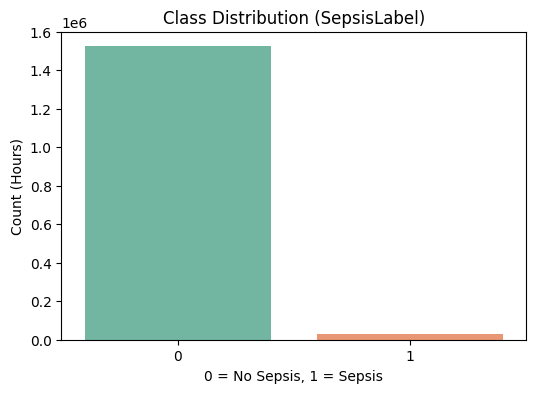

Percentage of Sepsis positive rows: 1.80%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='SepsisLabel', palette='Set2')
plt.title("Class Distribution (SepsisLabel)")
plt.xlabel("0 = No Sepsis, 1 = Sepsis")
plt.ylabel("Count (Hours)")
plt.savefig(f"{project_dir}/class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("Percentage of Sepsis positive rows: {:.2f}%".format(df['SepsisLabel'].mean() * 100))


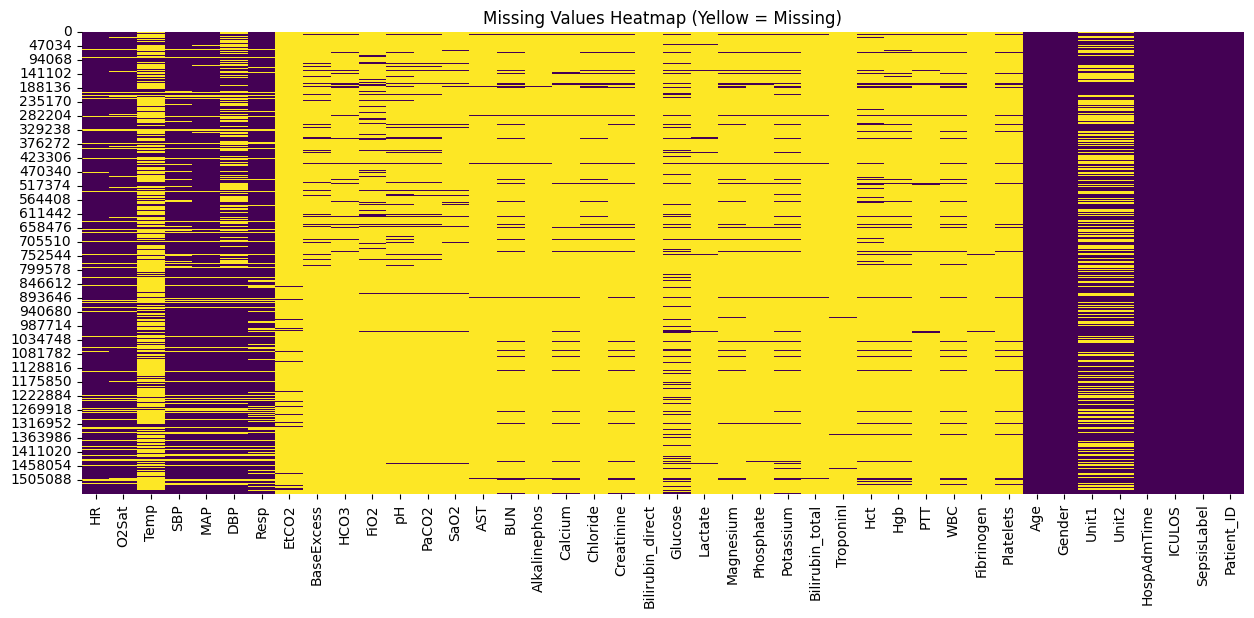


Top 10 features with most missing values:
Bilirubin_direct    99.807359
Fibrinogen          99.340125
TroponinI           99.047685
Bilirubin_total     98.509129
Alkalinephos        98.393158
AST                 98.377567
Lactate             97.329769
PTT                 97.056142
SaO2                96.549607
EtCO2               96.286611
dtype: float64


In [ ]:
# Plot 2: Missing Values Heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Yellow = Missing)")
plt.savefig(f"{project_dir}/missing_values_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Calculate missing percentages
missing_pct = df.isnull().mean() * 100
print("\nTop 10 features with most missing values:")
print(missing_pct.sort_values(ascending=False).head(10))


/tmp/ipykernel_1661/2625463004.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SepsisLabel', y='HR', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_1661/2625463004.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SepsisLabel', y='Temp', data=df, ax=axes[1], palette='pastel')
/tmp/ipykernel_1661/2625463004.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SepsisLabel', y='WBC', data=df, ax=axes[2], palette='pastel')


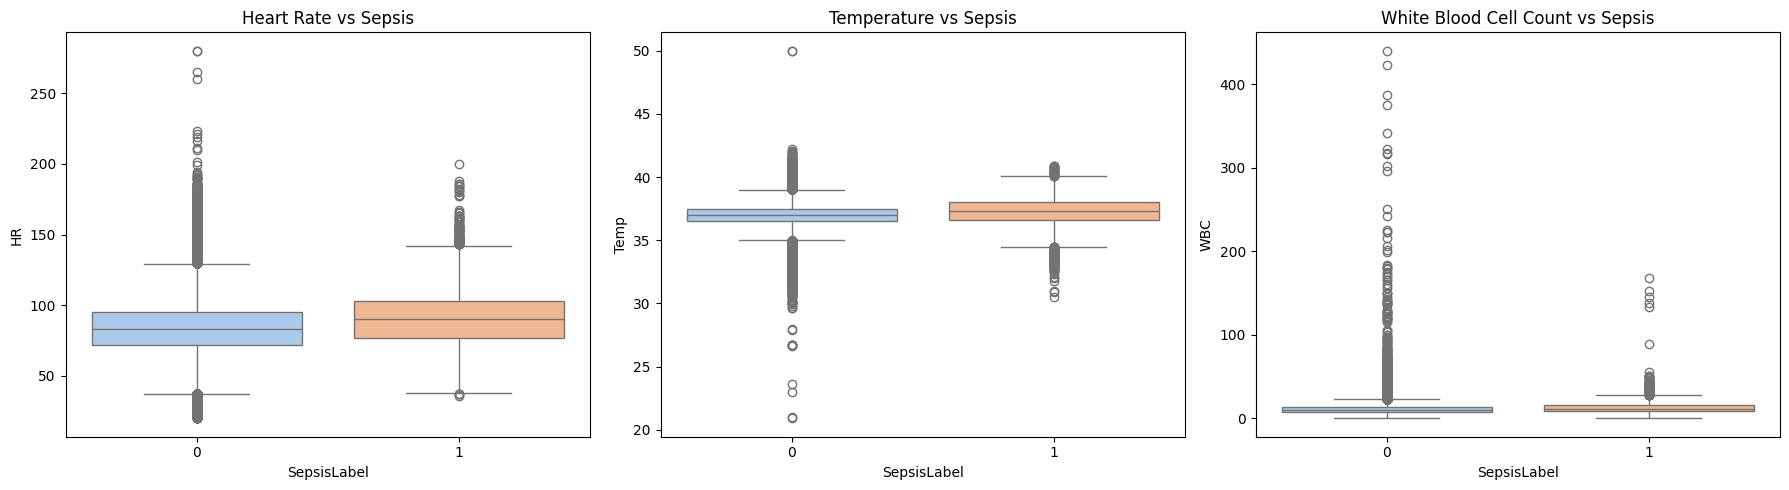

In [ ]:
# Plot 3: Vitals Distribution (Sepsis vs No Sepsis)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='SepsisLabel', y='HR', data=df, ax=axes[0], palette='pastel')
axes[0].set_title("Heart Rate vs Sepsis")

sns.boxplot(x='SepsisLabel', y='Temp', data=df, ax=axes[1], palette='pastel')
axes[1].set_title("Temperature vs Sepsis")

sns.boxplot(x='SepsisLabel', y='WBC', data=df, ax=axes[2], palette='pastel')
axes[2].set_title("White Blood Cell Count vs Sepsis")

plt.tight_layout()
plt.savefig(f"{project_dir}/vitals_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


## 5. Advanced Feature Engineering & Data Preprocessing
We handle missing values and engineer time-series dynamics (volatility, extremes).

In [ ]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

print("Starting Advanced Preprocessing...")

# 1. Drop features with > 90% missing values
missing_threshold = 0.90
cols_to_keep = df.columns[df.isnull().mean() < missing_threshold]
df = df[cols_to_keep]

# 2. Safely Forward fill per patient
cols_to_ffill = [c for c in df.columns if c != 'Patient_ID']
df[cols_to_ffill] = df.groupby('Patient_ID')[cols_to_ffill].ffill()

# 3. Median Imputation for any remaining NaNs
df = df.fillna(df.median(numeric_only=True))

# 4. Advanced Time-Series Feature Engineering
vitals = ['HR', 'MAP', 'O2Sat', 'Resp', 'SBP']
print("Calculating time-series dynamics (Means, Volatility, Extremes)...")

tqdm.pandas(desc="Processing Vitals")

for v in vitals:
    if v in df.columns:
        grouped = df.groupby('Patient_ID')[v]

        # 3-Hour and 6-Hour Trends (Means)
        df[f'{v}_mean_3h'] = grouped.rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
        df[f'{v}_mean_6h'] = grouped.rolling(window=6, min_periods=1).mean().reset_index(level=0, drop=True)

        # 6-Hour Volatility (Standard Deviation)
        df[f'{v}_std_6h'] = grouped.rolling(window=6, min_periods=1).std().reset_index(level=0, drop=True).fillna(0)

        # 6-Hour Extremes (Min and Max)
        df[f'{v}_max_6h'] = grouped.rolling(window=6, min_periods=1).max().reset_index(level=0, drop=True)
        df[f'{v}_min_6h'] = grouped.rolling(window=6, min_periods=1).min().reset_index(level=0, drop=True)

print("\nAdvanced Preprocessing complete!")
print(f"Total features created: {df.shape[1]}")
df.head()

Starting Advanced Preprocessing...
Calculating time-series dynamics (Means, Volatility, Extremes)...

Advanced Preprocessing complete!
Total features created: 41


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Glucose,Age,Gender,...,Resp_mean_3h,Resp_mean_6h,Resp_std_6h,Resp_max_6h,Resp_min_6h,SBP_mean_3h,SBP_mean_6h,SBP_std_6h,SBP_max_6h,SBP_min_6h
0,83.0,98.0,36.830002,121.0,81.0,62.0,18.0,122.0,74.050003,0,...,18.000000,18.0,0.000000,18.0,18.0,121.000000,121.0,0.000000,121.0,121.0
1,90.0,97.0,36.830002,131.0,87.0,58.0,19.0,122.0,74.050003,0,...,18.500000,18.5,0.707107,19.0,18.0,126.000000,126.0,7.071068,131.0,121.0
2,85.0,96.0,36.830002,102.0,63.0,43.0,17.0,122.0,74.050003,0,...,18.000000,18.0,1.000000,19.0,17.0,118.000000,118.0,14.730920,131.0,102.0
3,88.0,96.0,36.830002,118.0,73.0,48.0,18.0,84.0,74.050003,0,...,18.000000,18.0,0.816497,19.0,17.0,117.000000,118.0,12.027746,131.0,102.0
4,81.0,96.0,37.830002,91.0,74.5,60.0,20.0,84.0,74.050003,0,...,18.333333,18.4,1.140175,20.0,17.0,103.666667,112.6,15.946787,131.0,91.0


## 6. Train-Test Split and Scaling
We use GroupShuffleSplit to prevent data leakage and standard scaling. We skip SMOTE to use XGBoost class weights instead.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

print("Splitting data (Grouping by Patient to prevent data leakage)...")

X = df.drop(columns=['SepsisLabel', 'Patient_ID'])
y = df['SepsisLabel']
groups = df['Patient_ID']

# 80/20 split based on Patient_ID
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]
X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

print("Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train Shape: {X_train_scaled.shape}, Test Shape: {X_test_scaled.shape}")
print(f"Sepsis cases in training: {sum(y_train == 1)}")

Splitting data (Grouping by Patient to prevent data leakage)...
Standardizing features...
Train Shape: (1243328, 39), Test Shape: (308785, 39)
Sepsis cases in training: 22401


## 7. Model Training (Weighted XGBoost)
We train a hyper-tuned XGBoost model utilizing `scale_pos_weight`.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import joblib

# 1. Calculate the class weight ratio
pos_cases = sum(y_train == 1)
neg_cases = sum(y_train == 0)
weight_ratio = neg_cases / pos_cases
print(f"Class Imbalance Ratio (Neg/Pos): {weight_ratio:.2f}")
print(f"Applying scale_pos_weight = {weight_ratio:.2f} to XGBoost...")

# 2. Hyper-Tuned XGBoost
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=weight_ratio,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("\nTraining Weighted XGBoost...")
xgb_model.fit(X_train_scaled, y_train)

print("\nTraining Complete! Standard 0.5 Threshold Results:")
y_pred = xgb_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Save model
xgb_model_path = f"{project_dir}/xgboost_model_advanced.pkl"
joblib.dump(xgb_model, xgb_model_path)
print(f"Model saved to Drive: {xgb_model_path}")

Class Imbalance Ratio (Neg/Pos): 54.50
Applying scale_pos_weight = 54.50 to XGBoost...

Training Weighted XGBoost...

Training Complete! Standard 0.5 Threshold Results:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    303270
           1       0.07      0.55      0.12      5515

    accuracy                           0.85    308785
   macro avg       0.53      0.71      0.52    308785
weighted avg       0.97      0.85      0.91    308785

Model saved to Drive: /content/drive/MyDrive/Sepsis_Detection_Project/xgboost_model_advanced.pkl


## 8. Evaluation & Visualizations
We evaluate models and save the Confusion Matrices and ROC-AUC curves to Drive.


=== Weighted XGBoost Report ===
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    303270
           1       0.07      0.55      0.12      5515

    accuracy                           0.85    308785
   macro avg       0.53      0.71      0.52    308785
weighted avg       0.97      0.85      0.91    308785



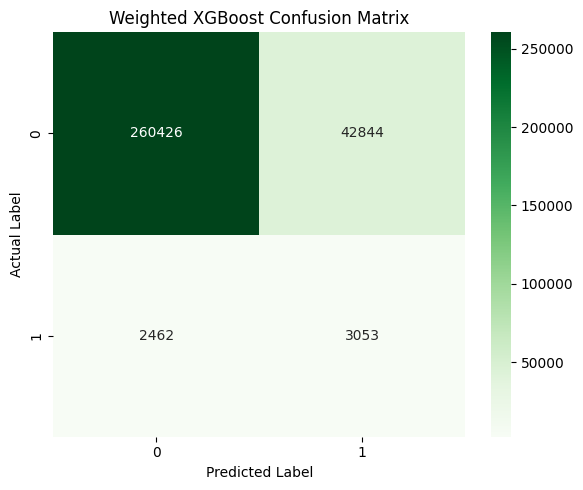

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# We use the scaled test data for our hyper-tuned model!
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=== Weighted XGBoost Report ===")
print(classification_report(y_test, xgb_preds))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', cmap='Greens')
plt.title('Weighted XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f"{project_dir}/confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

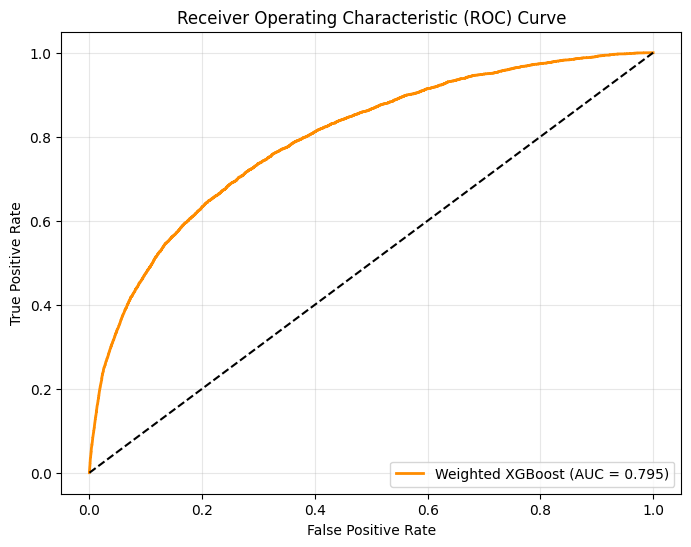

In [ ]:
# ROC Curve Visualization
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8, 6))
plt.plot(xgb_fpr, xgb_tpr, label=f'Weighted XGBoost (AUC = {roc_auc_score(y_test, xgb_probs):.3f})', color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(f"{project_dir}/roc_auc_curves.png", dpi=300, bbox_inches='tight')
plt.show()

## 9. Model Interpretability with SHAP
We will save the SHAP summary plot to Drive as well.


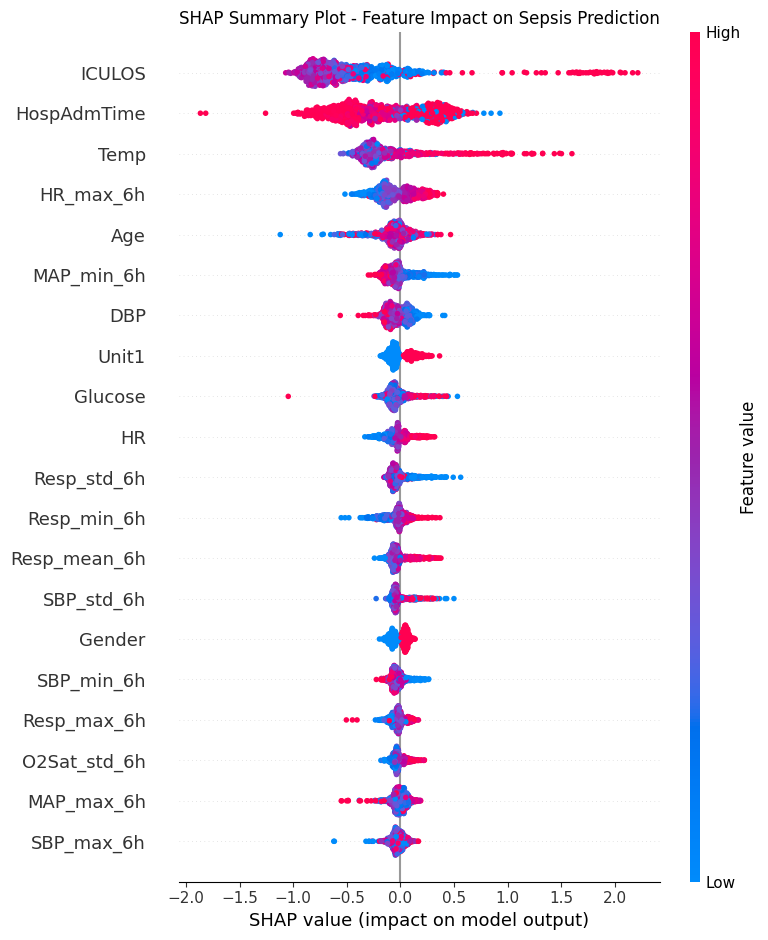

In [ ]:
import shap
import pandas as pd
shap.initjs()

explainer = shap.TreeExplainer(xgb_model)

# We must convert the scaled numpy array back to a DataFrame so SHAP knows the feature names!
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Sample 1000 patients for the SHAP summary to save memory and time
X_test_sample = X_test_scaled_df.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Summary Plot
plt.figure()
plt.title("SHAP Summary Plot - Feature Impact on Sepsis Prediction")
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.savefig(f"{project_dir}/shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

## 10. Threshold Tuning and Precision-Recall Tradeoff

=== Threshold Tuning Results ===
Threshold 0.30 -> Precision: 0.039 | Recall: 0.770 | F1: 0.075
Threshold 0.50 -> Precision: 0.067 | Recall: 0.554 | F1: 0.119
Threshold 0.70 -> Precision: 0.109 | Recall: 0.348 | F1: 0.166
Threshold 0.85 -> Precision: 0.170 | Recall: 0.170 | F1: 0.170


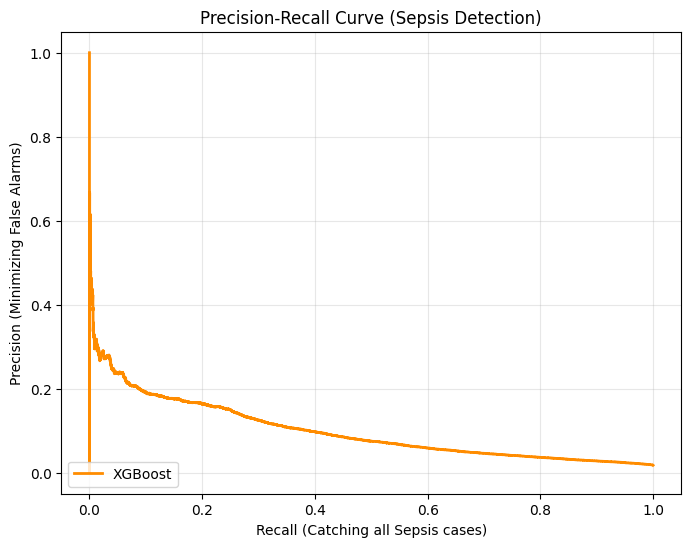

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

# Get the raw probabilities from the model
y_pred_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=== Threshold Tuning Results ===")
thresholds_to_test = [0.3, 0.5, 0.7, 0.85]

for thresh in thresholds_to_test:
    custom_preds = (y_pred_prob >= thresh).astype(int)
    p = precision_score(y_test, custom_preds)
    r = recall_score(y_test, custom_preds)
    f = f1_score(y_test, custom_preds)
    print(f"Threshold {thresh:.2f} -> Precision: {p:.3f} | Recall: {r:.3f} | F1: {f:.3f}")

# Plot the Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='XGBoost', color='darkorange', linewidth=2)
plt.xlabel('Recall (Catching all Sepsis cases)')
plt.ylabel('Precision (Minimizing False Alarms)')
plt.title('Precision-Recall Curve (Sepsis Detection)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.savefig(f"{project_dir}/precision_recall_curve.png")
plt.show()

# Simulate a Real-Time ICU Patient Test

Simulating Real-Time ICU Monitoring for Patient: p003079


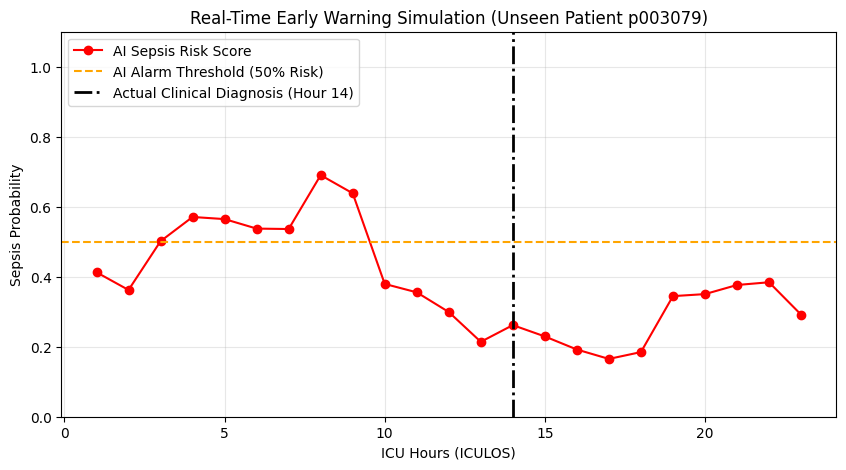

In [ ]:
import matplotlib.pyplot as plt

df_test = df.iloc[test_idx]

# Find patients who got sepsis
sepsis_patients = df_test[df_test['SepsisLabel'] == 1]

# Filter for patients who were diagnosed AFTER at least 15 hours in the ICU
late_sepsis_patients = sepsis_patients[sepsis_patients['ICULOS'] > 15]['Patient_ID'].unique()

# Pick the first one from this filtered list
test_patient_id = late_sepsis_patients[0]
print(f"Simulating Real-Time ICU Monitoring for Patient: {test_patient_id}")

patient_data_raw = df_test[df_test['Patient_ID'] == test_patient_id].sort_values(by='ICULOS')
patient_actual_labels = patient_data_raw['SepsisLabel']

patient_X = patient_data_raw.drop(columns=['SepsisLabel', 'Patient_ID'])
patient_X_scaled = scaler.transform(patient_X)
patient_risk_scores = xgb_model.predict_proba(patient_X_scaled)[:, 1]

clinical_sepsis_hour = patient_data_raw[patient_actual_labels == 1]['ICULOS'].iloc[0]

plt.figure(figsize=(10, 5))
plt.plot(patient_data_raw['ICULOS'], patient_risk_scores, marker='o', linestyle='-', color='red', label='AI Sepsis Risk Score')
plt.axhline(y=0.5, color='orange', linestyle='--', label='AI Alarm Threshold (50% Risk)')
plt.axvline(x=clinical_sepsis_hour, color='black', linestyle='-.', linewidth=2, label=f'Actual Clinical Diagnosis (Hour {clinical_sepsis_hour})')

plt.title(f'Real-Time Early Warning Simulation (Unseen Patient {test_patient_id})')
plt.xlabel('ICU Hours (ICULOS)')
plt.ylabel('Sepsis Probability')
plt.ylim(0, 1.1)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

# Save the plot to Drive
plt.savefig(f"{project_dir}/patient_simulation_early_warning.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np

# Create a list to store the early warning times
early_warning_hours = []
missed_or_late = 0

# Loop through all patients in the unseen test set who actually got Sepsis
print(f"Analyzing all {len(patient_ids_with_sepsis)} Sepsis patients in the test set...")

for pid in patient_ids_with_sepsis:
    # Get this patient's chronological data
    p_data = df_test[df_test['Patient_ID'] == pid].sort_values(by='ICULOS')

    # Find the clinical diagnosis hour (when SepsisLabel first becomes 1)
    t_clinical = p_data[p_data['SepsisLabel'] == 1]['ICULOS'].iloc[0]

    # Prepare data for model prediction
    p_X = p_data.drop(columns=['SepsisLabel', 'Patient_ID'])
    p_X_scaled = scaler.transform(p_X)

    # Get AI predictions
    p_probs = xgb_model.predict_proba(p_X_scaled)[:, 1]

    # Find the first hour the AI risk score hits >= 0.5
    ai_alarms = p_data[p_probs >= 0.5]['ICULOS']

    if len(ai_alarms) > 0:
        t_ai = ai_alarms.iloc[0] # The very first time the alarm goes off

        # Did we catch it early or exactly on time?
        if t_ai <= t_clinical:
            early_warning_hours.append(t_clinical - t_ai)
        else:
            missed_or_late += 1
    else:
        # AI never reached 50% risk for this patient
        missed_or_late += 1

# Calculate the final metrics
avg_early_warning = np.mean(early_warning_hours)
max_early_warning = np.max(early_warning_hours)
median_early_warning = np.median(early_warning_hours)

print("-" * 50)
print(f"Total Sepsis Patients Analyzed: {len(patient_ids_with_sepsis)}")
print(f"Successfully Detected Early (or on time): {len(early_warning_hours)} patients")
print(f"Missed or Detected Late: {missed_or_late} patients")
print("-" * 50)
print(f"AVERAGE Early Warning Time: {avg_early_warning:.1f} hours before diagnosis")
print(f"MEDIAN Early Warning Time:  {median_early_warning:.1f} hours before diagnosis")
print(f"MAXIMUM Early Warning Time: {max_early_warning:.1f} hours before diagnosis")

Analyzing all 577 Sepsis patients in the test set...
--------------------------------------------------
Total Sepsis Patients Analyzed: 577
Successfully Detected Early (or on time): 430 patients
Missed or Detected Late: 147 patients
--------------------------------------------------
AVERAGE Early Warning Time: 50.3 hours before diagnosis
MEDIAN Early Warning Time:  29.5 hours before diagnosis
MAXIMUM Early Warning Time: 323.0 hours before diagnosis


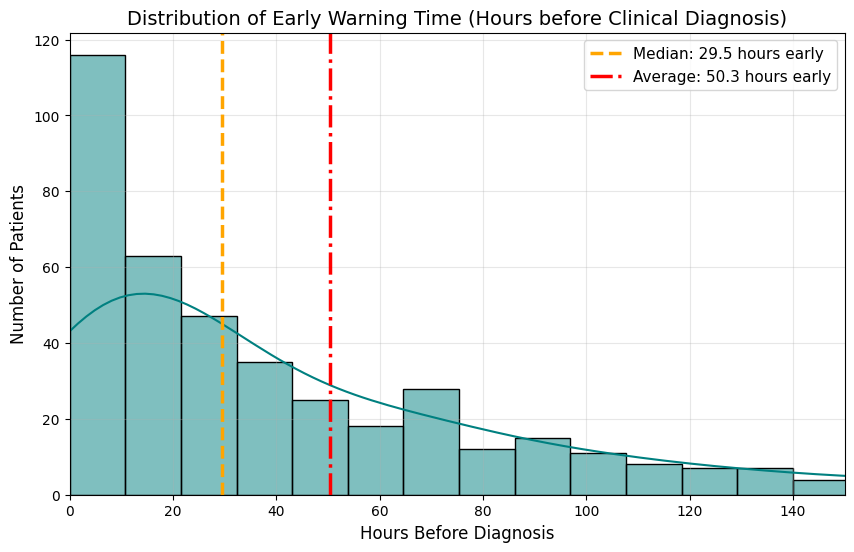

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Create a histogram with a smooth density curve (KDE)
sns.histplot(early_warning_hours, bins=30, kde=True, color='teal', edgecolor='black')

# Add vertical lines for the Median and Average
plt.axvline(median_early_warning, color='orange', linestyle='--', linewidth=2.5,
            label=f'Median: {median_early_warning:.1f} hours early')
plt.axvline(avg_early_warning, color='red', linestyle='-.', linewidth=2.5,
            label=f'Average: {avg_early_warning:.1f} hours early')

plt.title('Distribution of Early Warning Time (Hours before Clinical Diagnosis)', fontsize=14)
plt.xlabel('Hours Before Diagnosis', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Limit the x-axis to 150 hours to zoom in on the majority of patients (ignoring extreme outliers)
plt.xlim(0, 150)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Save the plot to your drive
plt.savefig(f"{project_dir}/early_warning_distribution.png", dpi=300, bbox_inches='tight')
plt.show()